# Phase 3 — Per-Venue Microstructure

Load the snapshot CSV produced by `scripts/fetch_snapshot.py` and visualize per-venue spread, depth, and book shape across the 3 NBA Finals pairs.

To refresh the snapshot:
```bash
uv run python scripts/fetch_snapshot.py
```

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.family"] = "monospace"

df = pd.read_csv("../data/processed/microstructure_snapshot.csv")
print(f"Loaded {len(df)} rows")
df

Loaded 11 rows


,venue,market_id,side,fetched_at,best_bid,best_ask,best_bid_size,best_ask_size,mid_simple,mid_size_weighted,spread_abs,spread_bps,depth_top_of_book,depth_within_1c,depth_within_5c,n_bid_levels,n_ask_levels
0,kalshi,nba_finals_okc,yes,2026-05-25T22:09:56.412510+00:00,0.470,0.480,230863.82,199.37,0.4750,0.479991,0.010,210.526316,231063.19,231063.19,1590606.92,32,48
1,kalshi,nba_finals_okc,no,2026-05-25T22:09:56.412510+00:00,0.520,0.530,199.37,230863.82,0.5250,0.520009,0.010,190.476190,231063.19,231063.19,1590606.92,48,32
2,polymarket,nba_finals_okc,yes,2026-05-25T22:09:56.412510+00:00,0.480,0.490,87415.10,12031.22,0.4850,0.488790,0.010,206.185567,99446.32,99446.32,219927.59,41,44
3,polymarket,nba_finals_okc,no,2026-05-25T22:09:56.412510+00:00,0.510,0.520,12031.22,87415.10,0.5150,0.511210,0.010,194.174757,99446.32,99446.32,219927.59,44,41
4,kalshi,nba_finals_cle,yes,2026-05-25T22:09:59.946763+00:00,NaN,0.010,NaN,3956692.33,NaN,NaN,NaN,NaN,3956692.33,0.00,0.00,0,73
5,kalshi,nba_finals_cle,no,2026-05-25T22:09:59.946763+00:00,0.990,NaN,3956692.33,NaN,NaN,NaN,NaN,NaN,3956692.33,0.00,0.00,73,0
6,polymarket,nba_finals_cle,yes,2026-05-25T22:09:59.946763+00:00,0.004,0.005,805.31,33351.94,0.0045,0.004024,0.001,2222.222222,34157.25,1978671.42,2062990.15,4,138
7,polymarket,nba_finals_cle,no,2026-05-25T22:09:59.946763+00:00,0.995,0.996,33351.94,805.31,0.9955,0.995976,0.001,10.045203,34157.25,1978671.42,2062990.15,138,4
8,kalshi,nba_finals_nyk,yes,2026-05-25T22:10:03.244554+00:00,0.250,0.270,448055.09,285216.38,0.2600,0.262221,0.020,769.230769,733271.47,733271.47,1638266.69,24,73
9,kalshi,nba_finals_nyk,no,2026-05-25T22:10:03.244554+00:00,0.730,0.750,285216.38,448055.09,0.7400,0.737779,0.020,270.270270,733271.47,733271.47,1638976.69,73,24


## Summary table — YES side, all 3 markets, both venues

In [2]:
yes_df = df[df["side"] == "yes"].copy()
cols = ["venue", "market_id", "best_bid", "best_ask", "spread_abs", "spread_bps",
        "depth_top_of_book", "depth_within_1c", "n_bid_levels", "n_ask_levels"]
yes_df[cols].sort_values(["market_id", "venue"])

,venue,market_id,best_bid,best_ask,spread_abs,spread_bps,depth_top_of_book,depth_within_1c,n_bid_levels,n_ask_levels
4,kalshi,nba_finals_cle,NaN,0.010,NaN,NaN,3956692.33,0.00,0,73
6,polymarket,nba_finals_cle,0.004,0.005,0.001,2222.222222,34157.25,1978671.42,4,138
8,kalshi,nba_finals_nyk,0.250,0.270,0.020,769.230769,733271.47,733271.47,24,73
10,polymarket,nba_finals_nyk,0.258,0.259,0.001,38.684720,296.94,39997.26,132,97
0,kalshi,nba_finals_okc,0.470,0.480,0.010,210.526316,231063.19,231063.19,32,48
2,polymarket,nba_finals_okc,0.480,0.490,0.010,206.185567,99446.32,99446.32,41,44


## Figure 1 — Spread comparison (bps) by market and venue

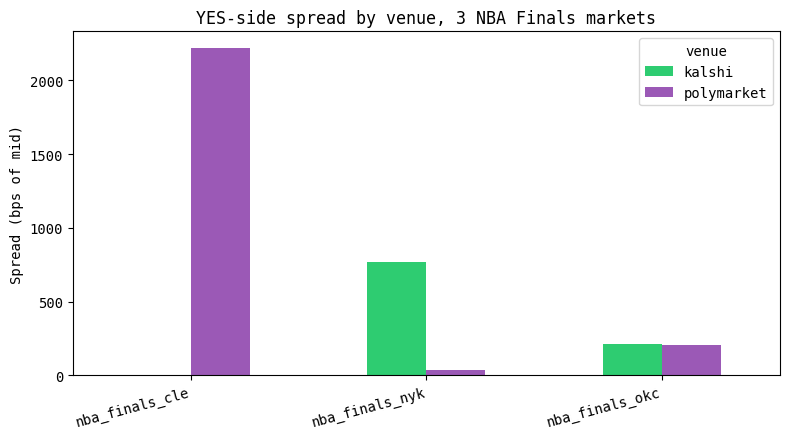

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pivot = yes_df.pivot_table(index="market_id", columns="venue", values="spread_bps")
pivot.plot(kind="bar", ax=ax, color=["#2ecc71", "#9b59b6"])
ax.set_ylabel("Spread (bps of mid)")
ax.set_title("YES-side spread by venue, 3 NBA Finals markets")
ax.set_xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../data/processed/fig_spread_by_venue.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 — Depth within 1¢ of mid

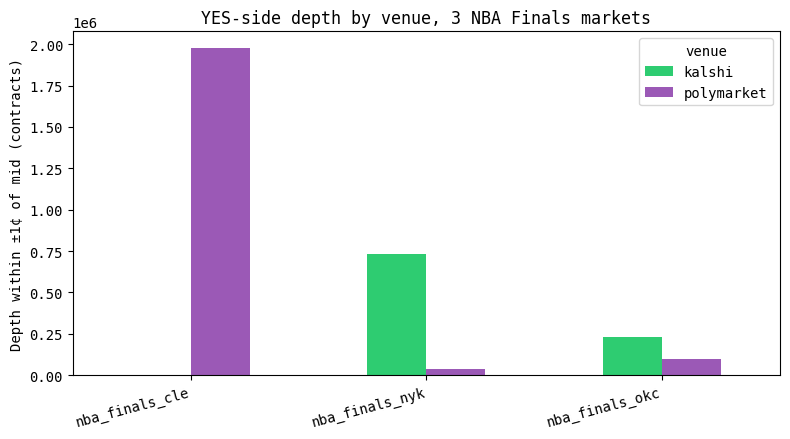

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pivot = yes_df.pivot_table(index="market_id", columns="venue", values="depth_within_1c")
pivot.plot(kind="bar", ax=ax, color=["#2ecc71", "#9b59b6"])
ax.set_ylabel("Depth within ±1¢ of mid (contracts)")
ax.set_title("YES-side depth by venue, 3 NBA Finals markets")
ax.set_xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../data/processed/fig_depth_1c.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 — Book shape (price levels populated)

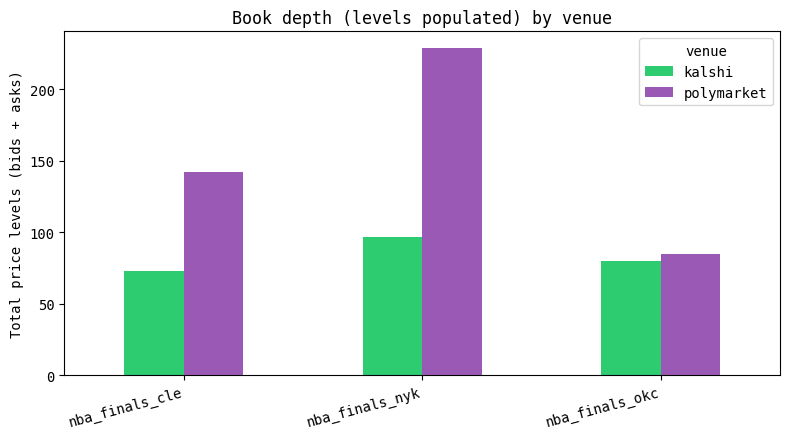

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
yes_df["total_levels"] = yes_df["n_bid_levels"] + yes_df["n_ask_levels"]
pivot = yes_df.pivot_table(index="market_id", columns="venue", values="total_levels")
pivot.plot(kind="bar", ax=ax, color=["#2ecc71", "#9b59b6"])
ax.set_ylabel("Total price levels (bids + asks)")
ax.set_title("Book depth (levels populated) by venue")
ax.set_xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../data/processed/fig_book_levels.png", dpi=150, bbox_inches="tight")
plt.show()

## Side-by-side reading

The three figures together describe the per-venue microstructure at this snapshot. Phase 4 builds on this to compute cross-venue mid-price discrepancy and executable arb after fees.